# 02 · Smoke train (Stage A — final gate before Stage B)

20 subjects × 2 epochs on CPU with `configs/train.smoke.yaml`. This is the gate
before the supercomputer run (spec §15 Stage A step 10). It confirms:
1. the full train/eval loop runs (op order: raw evidence → volume scale → modality
   dropout → fuse → loss),
2. the §12 invariant tests all pass,
3. the §13 monitors behave (S in range, S(wrong) ≤ S(correct), evidence balance).

Run: `uv run jupyter nbconvert --to notebook --execute --inplace notebooks/02_smoke_train.ipynb`

In [1]:
import os, sys
from pathlib import Path
os.environ["HF_HUB_OFFLINE"] = "1"; os.environ["TRANSFORMERS_OFFLINE"] = "1"
_root = Path.cwd()
while not (_root / "data" / "metadata").exists():
    _root = _root.parent
os.chdir(_root); sys.path.insert(0, str(_root))

%matplotlib inline
import numpy as np, matplotlib.pyplot as plt, torch
from torch.utils.data import DataLoader
from openidh_model.utils.paths import load_paths
from openidh_model.utils.config import load_config
from openidh_model.train.loop import train_fold, evaluate
from openidh_model.train.monitor import summarize, format_summary

paths = load_paths("configs/paths.local.yaml")
cfg = load_config(paths.root / "configs", "train.smoke.yaml")
cfg["train"], cfg["data"]

/workspace/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


({'finetune': 'full',
  'optimizer': 'adamw',
  'lr': 0.0001,
  'weight_decay': 0.05,
  'warmup_epochs': 3,
  'batch_size': 4,
  'epochs': 2,
  'early_stop_metric': 'nll',
  'early_stop_patience': 99,
  'modality_dropout_p': 0.2,
  'device': 'cpu',
  'amp_dtype': None},
 {'modalities': ['T1', 'T2', 'FLAIR', 'T1c'],
  'n_slices': 3,
  'image_size': 224,
  'volume_label': 'whole_tumor',
  'split_file': 'splits_loso_foldA.csv',
  'subset_n': 20})

## Train (smoke): 20 subjects × 2 epochs

In [2]:
res = train_fold(paths, cfg, cfg["data"]["split_file"], seed=0)
import pandas as pd
pd.DataFrame(res["history"])[["epoch", "train_loss", "nll", "auc", "median_S", "lam_reg_t"]]

train=20 val=10 age_mean=49.5 age_std=16.1


epoch 0: train_loss=0.5010 val_nll=0.7117 val_auc=0.440 median_S=20.6


epoch 1: train_loss=0.3885 val_nll=0.6789 val_auc=0.640 median_S=22.3


,epoch,train_loss,nll,auc,median_S,lam_reg_t
0,0,0.500966,0.711661,0.44,20.647154,0.000000
1,1,0.388498,0.678917,0.64,22.313195,0.006667


## §13 monitoring on inner-val

In [3]:
metrics, rec = evaluate(res["model"], DataLoader(res["val_ds"], batch_size=4), cfg, cfg["train"]["device"])
print("val metrics:", {k: round(v, 3) for k, v in metrics.items()})
summary = summarize(rec)
print(format_summary(summary))

val metrics: {'nll': 0.679, 'brier': 0.243, 'ece': 0.13, 'mean_S': 22.338, 'median_S': 22.313, 'auc': 0.64, 'auprc': 0.764}
  median S              : 22.3   (target 10–120)
  S (correct) median    : 22.9
  S (wrong)   median    : 21.9   OK <= correct
  fused reg/data ratio  : 5.85  (data=0.254, reg=1.483)
  evidence balance      : T1=6.71, T2=3.58, FLAIR=3.57, T1c=4.21, unified=0.90, tabular=1.37


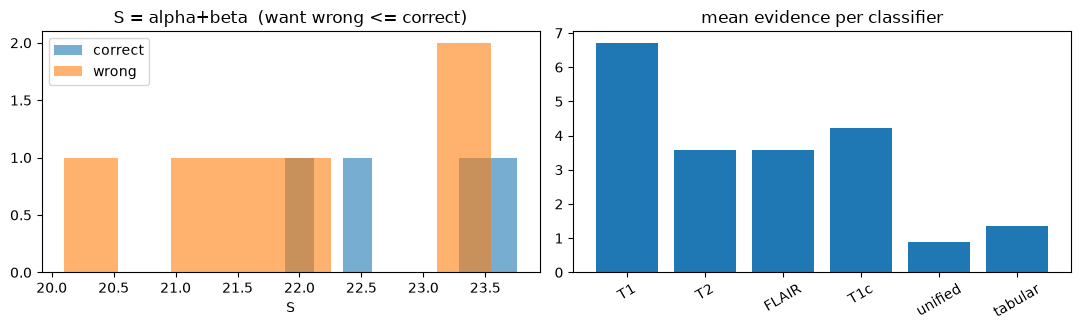

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
S, p, y = rec["S"], rec["p"], rec["y"]
correct = (p > 0.5).astype(int) == y.astype(int)
ax[0].hist(S[correct], bins=8, alpha=0.6, label="correct")
ax[0].hist(S[~correct], bins=8, alpha=0.6, label="wrong")
ax[0].set_title("S = alpha+beta  (want wrong <= correct)"); ax[0].set_xlabel("S"); ax[0].legend()
bal = summary["evidence_balance"]
ax[1].bar(list(bal.keys()), list(bal.values()))
ax[1].set_title("mean evidence per classifier"); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## §12 invariant tests (all must pass)

In [5]:
import subprocess
r = subprocess.run(["uv", "run", "pytest", "-q", "tests/test_invariants.py"],
                   cwd=str(paths.root), capture_output=True, text=True)
print(r.stdout[-1500:])
assert r.returncode == 0, "invariant tests FAILED"
print("§12 invariant tests: PASSED")

..............                                                           [100%]
14 passed in 2.45s

§12 invariant tests: PASSED


## ✅ Stage A gate passed
Loop runs, §12 tests pass, §13 monitors behave (S in the 10–120 target range,
S(wrong) ≤ S(correct), no dead/dominant classifier). Ready for **Stage B**:
change only `configs/paths.hpc.yaml` root, stage data + `weights/` + `uv.lock`,
run 1 fold, then all 9 folds × seeds across the 4 GPUs.

*(Smoke numbers are meaningless as performance — 20 subjects × 2 epochs — the point
is that the machinery and design invariants hold.)*